# Automated Data Collection Tool
**Authors:** Unaisa Islam, Dickson Owuor, Daisy Kipto, Raymond Cao

July 2025

## Main Goal

To write a function that will take as input: (1) a CSV file with image filters and (2) microscopy images. The function will apply filters to the images to produce graph images. The images will be later labeled as good/bad in order to be used to train a CNN model to detect/predict good and bad graph images.

### 1. Import Libraries

In [ ]:
# Installing Libraries (if not installed)
#!pip3 install matplotlib
#!pip3 install sgtlib
#!pip3 install seaborn
#!pip3 install numpy
#!pip3 install pandas

: 

In [102]:
import pandas
print(pandas.__file__)

/Users/raymondcao/Summer25/Data-Collection-CNN/structural-gt/.venv/lib/python3.13/site-packages/pandas/__init__.py


In [103]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg
from matplotlib import pyplot as plt

from sgtlib import modules as sgt

### 2. Get CSV file and Image Folder

['Sample3 SE_InL_002 - Small.tif', 'b-loofah', 'e-eggplant', 'Sample6 BSE_010 - Small.tif', 'i-squid', 'rGO.jpeg', 'CANF copy.jpeg', 'ANF copy.jpeg', 'Sample3 BSE_017.tif', 'Sample6 SE_InL_002 - Small.tif', 'CANF.jpeg', 'sgt_files', 'CCF.jpeg', 'Sample3 BSE_018 - Small.tif', 'FCF.jpeg', 'd-mushroom', 'f-jujube', 'h-sea cucumber', 'Sample3 SE_InL_003 - Small.tif', 'c-pomelo peel', 'Sample6 SE_InL_007.tif', 'a-sunflower receptacle', 'Sample6 SE_InL_006.tif', 'CANN copy.jpeg', 'j-nude mouse lung', 'Sample3 BSE_017 - Small.tif', 'FCF copy.jpeg', 'ANF.jpeg', 'Sample6 SE_InL_003 - Small.tif', 'CANN.jpeg', 'g-sponge', 'CCF copy.jpeg', 'Sample6 SE_InL_002.tif']
(664, 912, 3)


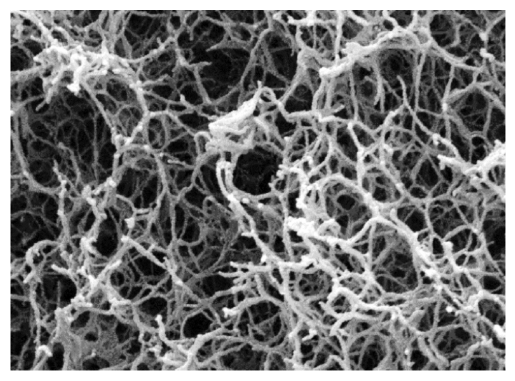

images/ANF.jpeg
Old Threshold Type: 0
New Threshold Type: 1
10: Processing image...
99.0: Image processing in progress...
100: Image processing complete...


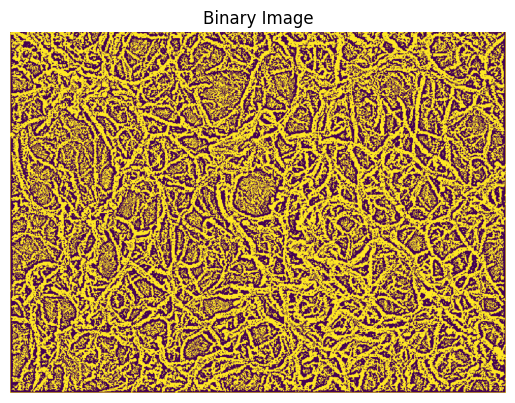

0: Starting graph extraction...
50: Extracting the graph network...
51: Build graph skeleton from binary image...
52: Ran merge_nodes for image skeleton...
54: Ran remove_small_objects for image skeleton...
56: Ran prune_dangling_edges for image skeleton...
60: Creating graph network...
64: Removing self loops from graph network...
66: Assigning weights to graph network...
75: Verifying graph network...
77: Retrieving graph properties...
78: Identifying graph subcomponents...
80: Storing graph properties...
90: Saving graph network...
95: Plotting graph network...


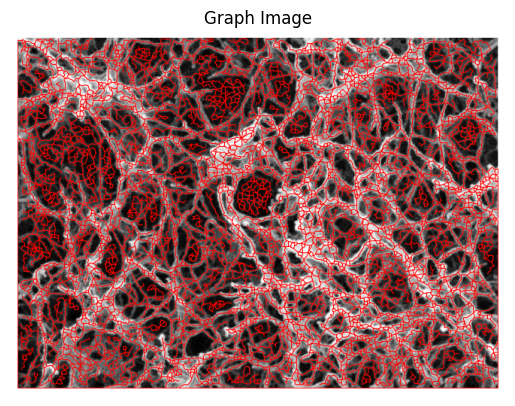

In [104]:
# Read CSV file into a Pandas DataFram

filter_df = pd.read_csv('../train_data/manual/filters.csv')
filter_df.head()

# Load images folder
data_dir = '../images'
os.listdir(data_dir)
print(os.listdir(data_dir))

# Check out images

img = mpimg.imread('../images/ANF.jpeg')
print(img.shape)
plt.imshow(img)
plt.axis('off')
plt.show()

# set paths
img_path = "../images/ANF.jpeg"
cfg_file = "sgt_configs.ini"  # Optional: leave blank

# Define a function for receiving progress updates
def print_updates(progress_val, progress_msg):
    print(f"{progress_val}: {progress_msg}")

# Create a Network object
ntwk_obj, _ = sgt.ImageProcessor.create_imp_object(img_path)

img_obj = ntwk_obj.image_obj
print(f"Old Threshold Type: {img_obj.configs["threshold_type"]["value"]}")

img_obj.configs["threshold_type"]["value"] = 1
print(f"New Threshold Type: {img_obj.configs["threshold_type"]["value"]}")

# Apply image filters according to cfg_file
ntwk_obj.add_listener(print_updates)
ntwk_obj.apply_img_filters()
ntwk_obj.remove_listener(print_updates)

# Get images
bin_image = ntwk_obj.binary_image_2d
mod_image = ntwk_obj.processed_image_2d

# View images
plt.imshow(bin_image)
plt.axis('off')  # Optional: Turn off axis ticks and labels for a cleaner image display
plt.title('Binary Image')
plt.show()

# Extract graph
ntwk_obj.add_listener(print_updates)
ntwk_obj.build_graph_network()
ntwk_obj.remove_listener(print_updates)

# View graph
net_image = ntwk_obj.graph_image
plt.imshow(net_image)
plt.axis('off')  # Optional: Turn off axis ticks and labels for a cleaner image display
plt.title('Graph Image')
plt.show()

In [91]:
# Read CSV file into a Pandas DataFram

filter_df = pd.read_csv('../train_data/manual/filters.csv')
filter_df.head()

,file_name,Adaptive Kernel,Global Threshold,OTSU,Dark FG,Autolevel,Gaussian Kernel,Laplacian,Sobel,Median,Scharr,Lowpass Window,Gamma,result
0,ANF copy.jpeg,21.0,NaN,NaN,NaN,7.0,7.0,NaN,NaN,True,NaN,3.0,0.94,G
1,ANF copy.jpeg,23.0,NaN,NaN,NaN,7.0,7.0,NaN,NaN,True,NaN,4.0,0.94,G
2,ANF copy.jpeg,25.0,NaN,NaN,NaN,7.0,7.0,NaN,NaN,True,NaN,3.0,0.97,G
3,ANF copy.jpeg,23.0,NaN,NaN,NaN,7.0,7.0,NaN,NaN,True,NaN,3.0,0.93,G
4,ANF copy.jpeg,11.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN,True,NaN,2.0,0.85,B


In [92]:
# Load images folder
data_dir = '../images'
os.listdir(data_dir)
print(os.listdir(data_dir))

['Sample3 SE_InL_002 - Small.tif', 'b-loofah', 'e-eggplant', 'Sample6 BSE_010 - Small.tif', 'i-squid', 'rGO.jpeg', 'CANF copy.jpeg', 'ANF copy.jpeg', 'Sample3 BSE_017.tif', 'Sample6 SE_InL_002 - Small.tif', 'CANF.jpeg', 'sgt_files', 'CCF.jpeg', 'Sample3 BSE_018 - Small.tif', 'FCF.jpeg', 'd-mushroom', 'f-jujube', 'h-sea cucumber', 'Sample3 SE_InL_003 - Small.tif', 'c-pomelo peel', 'Sample6 SE_InL_007.tif', 'a-sunflower receptacle', 'Sample6 SE_InL_006.tif', 'CANN copy.jpeg', 'j-nude mouse lung', 'Sample3 BSE_017 - Small.tif', 'FCF copy.jpeg', 'ANF.jpeg', 'Sample6 SE_InL_003 - Small.tif', 'CANN.jpeg', 'g-sponge', 'CCF copy.jpeg', 'Sample6 SE_InL_002.tif']


(664, 912, 3)


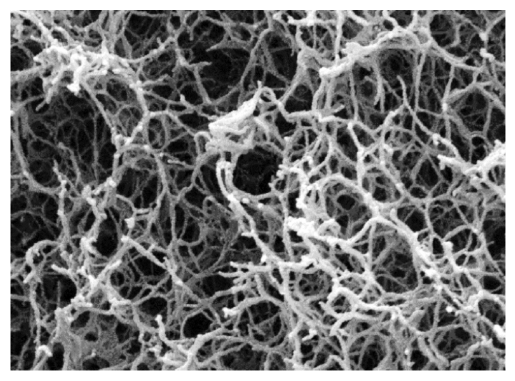

In [93]:
# Check out images

img = mpimg.imread('../images/ANF.jpeg')
print(img.shape)
plt.imshow(img)
plt.axis('off')
plt.show()

### 3. Run StructuralGT

* Identify and set paths to image(s) and config file

In [94]:
# set paths
img_path = "../images/ANF.jpeg"
cfg_file = "sgt_configs.ini"  # Optional: leave blank

* Define a function that will allow you to receive live updates from StructuralGT (as it is running)

In [95]:
# Define a function for receiving progress updates
def print_updates(progress_val, progress_msg):
    print(f"{progress_val}: {progress_msg}")

* Create an object that will take as input the config file and image and apply image filter

In [96]:
# Create a Network object
ntwk_obj, _ = sgt.ImageProcessor.create_imp_object(img_path)

images/ANF.jpeg


* Update image filter options

In [97]:
img_obj = ntwk_obj.image_obj
print(f"Old Threshold Type: {img_obj.configs["threshold_type"]["value"]}")

img_obj.configs["threshold_type"]["value"] = 1
print(f"New Threshold Type: {img_obj.configs["threshold_type"]["value"]}")

Old Threshold Type: 0
New Threshold Type: 1


* Apply image filters according to config file

In [98]:
# Apply image filters according to cfg_file
ntwk_obj.add_listener(print_updates)
ntwk_obj.apply_img_filters()
ntwk_obj.remove_listener(print_updates)

10: Processing image...
99.0: Image processing in progress...
100: Image processing complete...


In [99]:
# Get images
bin_image = ntwk_obj.binary_image_2d
mod_image = ntwk_obj.processed_image_2d

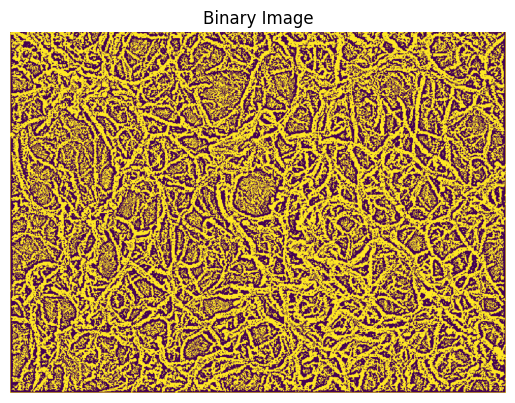

In [100]:
# View images
plt.imshow(bin_image)
plt.axis('off')  # Optional: Turn off axis ticks and labels for a cleaner image display
plt.title('Binary Image')
plt.show()

* Extract the graph

In [76]:
# Extract graph
ntwk_obj.add_listener(print_updates)
ntwk_obj.build_graph_network()
ntwk_obj.remove_listener(print_updates)

0: Starting graph extraction...
50: Extracting the graph network...
51: Build graph skeleton from binary image...
52: Ran merge_nodes for image skeleton...
54: Ran remove_small_objects for image skeleton...
56: Ran prune_dangling_edges for image skeleton...
60: Creating graph network...
64: Removing self loops from graph network...
66: Assigning weights to graph network...
75: Verifying graph network...
77: Retrieving graph properties...
78: Identifying graph subcomponents...
80: Storing graph properties...
90: Saving graph network...
95: Plotting graph network...


* View the graph image

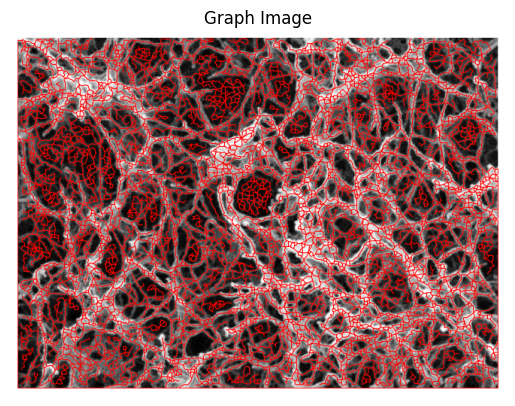

In [77]:
# View graph
net_image = ntwk_obj.graph_image
plt.imshow(net_image)
plt.axis('off')  # Optional: Turn off axis ticks and labels for a cleaner image display
plt.title('Graph Image')
plt.show()

In [ ]:
# # def automated_graph_generator():
# #     """"""
# #     # identify an image folder
# #     # Run 1, 2, 3 in a loop (if we want 10k, then the loop should repeat itself 10k times)
# #     # 1. randomly come with image filters
# #     # 2. apply them to all images
# #     # 3. save the graph images (with unique names) and the randomly selected filters (used to generate that graph - in CVS file with the file name of the graph image)
# #     pass

# def automated_graph_generator(
#     images_dir: str = "images",
#     out_dir: str = "auto_images",
#     csv_path: str = "filters_log.csv",
#     loops: int = 1000,
#     auto_filter_csv: str = "auto_filter.csv",
# ):
#     import random, uuid
#     from pathlib import Path
#     import pandas as pd
#     from matplotlib import pyplot as plt
#     from sgtlib import modules as sgt

#     exts = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp", ".gif"}
#     img_paths = [p for p in Path(images_dir).glob("**/*") if p.suffix.lower() in exts]
#     if not img_paths:
#         print(f"[automated_graph_generator] No images found in {images_dir}")
#         return

#     Path(out_dir).mkdir(parents=True, exist_ok=True)
#     Path(Path(auto_filter_csv).parent).mkdir(parents=True, exist_ok=True)

#     # detailed log (JSON-like)
#     filters_columns = [
#         "filename","class","src_relpath",
#         "threshold_type","global_threshold_value","adaptive_local_threshold_value",
#         "adjust_gamma","blurring_window_size","filter_window_size",
#         "apply_gamma","apply_autolevel","apply_laplacian_gradient","apply_scharr_gradient",
#         "apply_sobel_gradient","apply_median_filter","apply_gaussian_blur",
#         "apply_lowpass_filter","apply_dark_foreground",
#     ]

#     # “auto_filter.csv” 
#     af_columns = [
#         "file_name","Adaptive Kernel","Global Threshold","OTSU","Dark FG","Autolevel",
#         "Gaussian Kernel","Laplacian","Sobel","Median","Scharr","Lowpass Window","Gamma","result"
#     ]

#     def _apply_cfg(img_obj, cfg):
#         img_obj.configs["threshold_type"]["value"] = cfg["threshold_type"]
#         img_obj.configs["global_threshold_value"]["value"] = cfg["global_threshold_value"]
#         img_obj.configs["adaptive_local_threshold_value"]["value"] = cfg["adaptive_local_threshold_value"]
#         img_obj.configs["adjust_gamma"]["value"] = cfg["adjust_gamma"]
#         img_obj.configs["blurring_window_size"]["value"] = cfg["blurring_window_size"]
#         img_obj.configs["filter_window_size"]["value"] = cfg["filter_window_size"]
#         img_obj.configs["apply_gamma"]["value"] = cfg["apply_gamma"]
#         img_obj.configs["apply_autolevel"]["value"] = cfg["apply_autolevel"]
#         img_obj.configs["apply_laplacian_gradient"]["value"] = cfg["apply_laplacian_gradient"]
#         img_obj.configs["apply_scharr_gradient"]["value"] = cfg["apply_scharr_gradient"]
#         img_obj.configs["apply_sobel_gradient"]["value"] = cfg["apply_sobel_gradient"]
#         img_obj.configs["apply_median_filter"]["value"] = cfg["apply_median_filter"]
#         img_obj.configs["apply_gaussian_blur"]["value"] = cfg["apply_gaussian_blur"]
#         img_obj.configs["apply_lowpass_filter"]["value"] = cfg["apply_lowpass_filter"]
#         img_obj.configs["apply_dark_foreground"]["value"] = cfg["apply_dark_foreground"]

#     for run_idx in range(loops):
        
#         cfg = {
#             "threshold_type": random.choice([0, 1, 2]),                         # 0/1/2
#             "global_threshold_value": random.randint(1, 255),                   # 1..255
#             "adaptive_local_threshold_value": random.randrange(1, 1000, 2),     # odd 1..999
#             "adjust_gamma": round(random.randint(1, 500) / 100.0, 2),           # 0.01..5.00, 2 decimals
#             "blurring_window_size": random.choice([1, 3, 5, 7]),                # odd 1..7

#             # unchanged
#             "filter_window_size": random.randint(0, 999),
#             "apply_gamma": random.randint(0, 1),
#             "apply_autolevel": random.randint(0, 1),
#             "apply_laplacian_gradient": random.randint(0, 1),
#             "apply_scharr_gradient": random.randint(0, 1),
#             "apply_sobel_gradient": random.randint(0, 1),
#             "apply_median_filter": random.randint(0, 1),
#             "apply_gaussian_blur": random.randint(0, 1),
#             "apply_lowpass_filter": random.randint(0, 1),
#             "apply_dark_foreground": random.randint(0, 1),
#         }

#         rows = []
#         af_rows = []

#         for img_path in img_paths:
#             rel = img_path.relative_to(images_dir)
#             cls = rel.parts[0] if len(rel.parts) > 1 else "root"

#             out_subdir = Path(out_dir) / cls
#             out_subdir.mkdir(parents=True, exist_ok=True)

#             ntwk_obj, _ = sgt.ImageProcessor.create_imp_object(str(img_path))
#             _apply_cfg(ntwk_obj.image_obj, cfg)
#             ntwk_obj.build_graph_network()

#             uid = uuid.uuid4().hex[:8]
#             out_name = f"{img_path.stem}__run{run_idx:05d}__{uid}.png"
#             out_file = out_subdir / out_name

#             plt.figure()
#             plt.imshow(ntwk_obj.graph_image)
#             plt.axis("off")
#             plt.savefig(out_file, bbox_inches="tight", pad_inches=0)
#             plt.close()

#             # detailed row (kept from earlier)
#             row = {"filename": f"{cls}/{out_name}", "class": cls, "src_relpath": str(rel)}
#             row.update(cfg)
#             rows.append(row)

#             # auto_filter.csv row (matches your example format)
#             # mutually exclusive threshold columns by threshold_type
#             adaptive_kernel = str(cfg["adaptive_local_threshold_value"]) if cfg["threshold_type"] == 1 else ""
#             global_threshold = str(cfg["global_threshold_value"]) if cfg["threshold_type"] == 0 else ""
#             otsu = "TRUE" if cfg["threshold_type"] == 2 else ""

#             dark_fg = "TRUE" if cfg["apply_dark_foreground"] == 1 else ""
#             autolevel = "TRUE" if cfg["apply_autolevel"] == 1 else ""

#             gaussian_kernel = str(cfg["blurring_window_size"]) if cfg["apply_gaussian_blur"] == 1 else ""
#             laplacian = "TRUE" if cfg["apply_laplacian_gradient"] == 1 else ""
#             sobel = "TRUE" if cfg["apply_sobel_gradient"] == 1 else ""
#             median = "TRUE" if cfg["apply_median_filter"] == 1 else ""
#             scharr = "TRUE" if cfg["apply_scharr_gradient"] == 1 else ""
#             lowpass_window = str(cfg["filter_window_size"]) if cfg["apply_lowpass_filter"] == 1 else ""
#             gamma_str = f"{cfg['adjust_gamma']:.2f}" if cfg["apply_gamma"] == 1 else ""

#             af_rows.append({
#                 "file_name": img_path.name,
#                 "Adaptive Kernel": adaptive_kernel,
#                 "Global Threshold": global_threshold,
#                 "OTSU": otsu,
#                 "Dark FG": dark_fg,
#                 "Autolevel": autolevel,
#                 "Gaussian Kernel": gaussian_kernel,
#                 "Laplacian": laplacian,
#                 "Sobel": sobel,
#                 "Median": median,
#                 "Scharr": scharr,
#                 "Lowpass Window": lowpass_window,
#                 "Gamma": gamma_str,
#                 "result": "",   # leave blank; you can fill G/B later
#             })

#         # append batch to the detailed CSV
#         df = pd.DataFrame(rows, columns=filters_columns)
#         if Path(csv_path).exists():
#             df.to_csv(csv_path, mode="a", index=False, header=False)
#         else:
#             df.to_csv(csv_path, index=False, header=True)

#         # append batch to auto_filter.csv
#         af_df = pd.DataFrame(af_rows, columns=af_columns)
#         if Path(auto_filter_csv).exists():
#             af_df.to_csv(auto_filter_csv, mode="a", index=False, header=False)
#         else:
#             af_df.to_csv(auto_filter_csv, index=False, header=True)

#     print(f"[automated_graph_generator] Done. Outputs → '{out_dir}', logs → '{csv_path}' and '{auto_filter_csv}'.")


In [ ]:
import random, uuid
from pathlib import Path
import pandas as pd
from matplotlib import pyplot as plt
from sgtlib import modules as sgt

def automated3_graph_generator(
    images_dir: str = "images",
    out_dir: str = "auto_images",
    loops: int = 1000,
    auto_filter_csv: str = "auto_filter.csv",
):
    exts = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp", ".gif"}
    img_paths = [p for p in Path(images_dir).rglob("*") if p.suffix.lower() in exts]
    if not img_paths:
        print(f"[automated_graph_generator] No images found in {images_dir}")
        return

    out_subdir = Path(out_dir)
    out_subdir.mkdir(parents=True, exist_ok=True)

    Path(Path(auto_filter_csv).parent).mkdir(parents=True, exist_ok=True)

    af_columns = [
        "file_name","Adaptive Kernel","Global Threshold","OTSU","Dark FG","Autolevel",
        "Gaussian Kernel","Laplacian","Sobel","Median","Scharr","Lowpass Window","Gamma","result"
    ]

    print(str(img_paths[0]))
    for run_idx in range(loops):
        af_rows = []

        for img_path in img_paths:
            max_retries = 5
            attempt = 0
            success = False
            out_name = None
            cfg = None  # store the config that succeeded

            while attempt < max_retries and not success:
                # Generate new random config each retry
                cfg_try = {
                    "threshold_type": random.choice([0, 1, 2]),
                    "global_threshold_value": random.randint(1, 255),
                    "adaptive_local_threshold_value": random.randrange(1, 1000, 2),

                    "lut_gamma": round(random.randint(1, 500) / 100.0, 2),
                    "gaussian_blur_size": random.choice([1, 3, 5, 7]),
                    "autolevel_blur_size": random.choice([1, 3, 5, 7]),
                    "lowpass_window_size": random.randint(0, 1000),
                    "laplacian_kernel_size": random.choice([1, 3, 5, 7]),
                    "sobel_kernel_size": random.choice([1, 3, 5, 7]),

                    "apply_gamma": random.randint(0, 1),
                    "apply_autolevel": random.randint(0, 1),
                    "apply_gaussian_blur": random.randint(0, 1),
                    "apply_lowpass_filter": random.randint(0, 1),
                    "apply_laplacian_gradient": random.randint(0, 1),
                    "apply_sobel_gradient": random.randint(0, 1),
                    "apply_median_filter": random.randint(0, 1),
                    "apply_scharr_gradient": random.randint(0, 1),
                    "apply_dark_foreground": random.randint(0, 1),
                }

                # build SGT object and apply config
                ntwk_obj, _ = sgt.ImageProcessor.create_imp_object(str(img_path))
                cfgs = ntwk_obj.image_obj.configs

                cfgs["threshold_type"]["value"] = cfg_try["threshold_type"]
                cfgs["global_threshold_value"]["value"] = cfg_try["global_threshold_value"]
                cfgs["adaptive_local_threshold_value"]["value"] = cfg_try["adaptive_local_threshold_value"]
                cfgs["otsu"]["value"] = 1 if cfg_try["threshold_type"] == 2 else 0

                cfgs["apply_gamma"]["value"] = cfg_try["apply_gamma"]
                cfgs["apply_gamma"]["dataValue"] = cfg_try["lut_gamma"]

                cfgs["apply_autolevel"]["value"] = cfg_try["apply_autolevel"]
                cfgs["apply_autolevel"]["dataValue"] = cfg_try["autolevel_blur_size"]

                cfgs["apply_gaussian_blur"]["value"] = cfg_try["apply_gaussian_blur"]
                cfgs["apply_gaussian_blur"]["dataValue"] = cfg_try["gaussian_blur_size"]

                cfgs["apply_lowpass_filter"]["value"] = cfg_try["apply_lowpass_filter"]
                cfgs["apply_lowpass_filter"]["dataValue"] = cfg_try["lowpass_window_size"]

                cfgs["apply_laplacian_gradient"]["value"] = cfg_try["apply_laplacian_gradient"]
                cfgs["apply_laplacian_gradient"]["dataValue"] = cfg_try["laplacian_kernel_size"]

                cfgs["apply_sobel_gradient"]["value"] = cfg_try["apply_sobel_gradient"]
                cfgs["apply_sobel_gradient"]["dataValue"] = cfg_try["sobel_kernel_size"]

                cfgs["apply_median_filter"]["value"] = cfg_try["apply_median_filter"]
                cfgs["apply_scharr_gradient"]["value"] = cfg_try["apply_scharr_gradient"]
                cfgs["apply_dark_foreground"]["value"] = cfg_try["apply_dark_foreground"]

                try:
                    ntwk_obj.apply_img_filters()
                    ntwk_obj.build_graph_network()

                    if getattr(ntwk_obj, "graph_image", None) is None:
                        attempt += 1
                        continue

                    uid = uuid.uuid4().hex[:8]
                    out_name = f"{img_path.stem}__run{run_idx:05d}__{uid}.png"
                    out_file = out_subdir / out_name

                    plt.figure()
                    plt.imshow(ntwk_obj.graph_image)
                    plt.axis("off")
                    plt.savefig(out_file, bbox_inches="tight", pad_inches=0)
                    plt.close()

                    cfg = cfg_try  # save the successful config
                    success = True
                except Exception:
                    attempt += 1

            if not success:
                print(f"Skipping {img_path.name} after {max_retries} failed attempts.")
                continue

            # CSV row — use the config from the successful attempt
            adaptive_kernel = str(cfg["adaptive_local_threshold_value"]) if cfg["threshold_type"] == 1 else ""
            global_threshold = str(cfg["global_threshold_value"]) if cfg["threshold_type"] == 0 else ""
            otsu_str = "TRUE" if cfg["threshold_type"] == 2 else ""

            af_rows.append({
                "file_name": out_name,
                "Adaptive Kernel": adaptive_kernel,
                "Global Threshold": global_threshold,
                "OTSU": otsu_str,
                "Dark FG": "TRUE" if cfg["apply_dark_foreground"] == 1 else "",
                "Autolevel": str(cfg["autolevel_blur_size"]) if cfg["apply_autolevel"] == 1 else "",
                "Gaussian Kernel": str(cfg["gaussian_blur_size"]) if cfg["apply_gaussian_blur"] == 1 else "",
                "Laplacian": str(cfg["laplacian_kernel_size"]) if cfg["apply_laplacian_gradient"] == 1 else "",
                "Sobel": str(cfg["sobel_kernel_size"]) if cfg["apply_sobel_gradient"] == 1 else "",
                "Median": "TRUE" if cfg["apply_median_filter"] == 1 else "",
                "Scharr": "TRUE" if cfg["apply_scharr_gradient"] == 1 else "",
                "Lowpass Window": str(cfg["lowpass_window_size"]) if cfg["apply_lowpass_filter"] == 1 else "",
                "Gamma": f"{cfg['lut_gamma']:.2f}" if cfg["apply_gamma"] == 1 else "",
                "result": "",
            })

        # append this loop’s rows to auto_filter.csv
        if af_rows:
            af_df = pd.DataFrame(af_rows, columns=af_columns)
            if Path(auto_filter_csv).exists():
                af_df.to_csv(auto_filter_csv, mode="a", index=False, header=False)
            else:
                af_df.to_csv(auto_filter_csv, index=False, header=True)

    print(f"[automated_graph_generator] Done. Outputs → '{out_dir}', log → '{auto_filter_csv}'.")


In [172]:
automated3_graph_generator(loops=1)

images/h (1).tif
images/h (1).tif
images/j (6).tif
images/c (6).tif
images/d (2).tif
images/rGO copy.jpeg
images/CANF copy.jpeg
images/f (4).tif
images/j (7).tif


ERROR:root:Graph Extraction Error: max() iterable argument is empty
Traceback (most recent call last):
  File "/Users/raymondcao/Summer25/Data-Collection-CNN/structural-gt/.venv/lib/python3.13/site-packages/sgtlib/imaging/image_processor.py", line 442, in build_graph_network
    sel_batch.graph_obj.fit_graph(out_dir, img_bin, sel_batch.is_2d, px_size, rho_val, image_file=f_name)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/raymondcao/Summer25/Data-Collection-CNN/structural-gt/.venv/lib/python3.13/site-packages/sgtlib/networks/fiber_network.py", line 66, in fit_graph
    success = self.extract_graph(image_bin=img_bin, is_img_2d=is_img_2d, px_size=px_width_sz, rho_val=rho_val)
  File "/Users/raymondcao/Summer25/Data-Collection-CNN/structural-gt/.venv/lib/python3.13/site-packages/sgtlib/networks/fiber_network.py", line 158, in extract_graph
    giant_graph = max(sub_graphs, key=lambda g: g.number_of_nodes())
Value

images/j (7).tif
images/b (14).tif


ERROR:root:Graph Extraction Error: max() iterable argument is empty
Traceback (most recent call last):
  File "/Users/raymondcao/Summer25/Data-Collection-CNN/structural-gt/.venv/lib/python3.13/site-packages/sgtlib/imaging/image_processor.py", line 442, in build_graph_network
    sel_batch.graph_obj.fit_graph(out_dir, img_bin, sel_batch.is_2d, px_size, rho_val, image_file=f_name)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/raymondcao/Summer25/Data-Collection-CNN/structural-gt/.venv/lib/python3.13/site-packages/sgtlib/networks/fiber_network.py", line 66, in fit_graph
    success = self.extract_graph(image_bin=img_bin, is_img_2d=is_img_2d, px_size=px_width_sz, rho_val=rho_val)
  File "/Users/raymondcao/Summer25/Data-Collection-CNN/structural-gt/.venv/lib/python3.13/site-packages/sgtlib/networks/fiber_network.py", line 158, in extract_graph
    giant_graph = max(sub_graphs, key=lambda g: g.number_of_nodes())
Value

images/b (14).tif
images/ANF copy.jpeg
images/f (3).tif


...

images/a (4).BMP
images/e (4).tif
images/i (8).tif
images/d (6).tif
images/a (2).jpg


ERROR:root:Graph Extraction Error: max() iterable argument is empty
Traceback (most recent call last):
  File "/Users/raymondcao/Summer25/Data-Collection-CNN/structural-gt/.venv/lib/python3.13/site-packages/sgtlib/imaging/image_processor.py", line 442, in build_graph_network
    sel_batch.graph_obj.fit_graph(out_dir, img_bin, sel_batch.is_2d, px_size, rho_val, image_file=f_name)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/raymondcao/Summer25/Data-Collection-CNN/structural-gt/.venv/lib/python3.13/site-packages/sgtlib/networks/fiber_network.py", line 66, in fit_graph
    success = self.extract_graph(image_bin=img_bin, is_img_2d=is_img_2d, px_size=px_width_sz, rho_val=rho_val)
  File "/Users/raymondcao/Summer25/Data-Collection-CNN/structural-gt/.venv/lib/python3.13/site-packages/sgtlib/networks/fiber_network.py", line 158, in extract_graph
    giant_graph = max(sub_graphs, key=lambda g: g.number_of_nodes())
Value

images/a (2).jpg
images/h (5).tif
images/4_002.tif
images/4.tif


ERROR:root:Graph Extraction Error: max() iterable argument is empty
Traceback (most recent call last):
  File "/Users/raymondcao/Summer25/Data-Collection-CNN/structural-gt/.venv/lib/python3.13/site-packages/sgtlib/imaging/image_processor.py", line 442, in build_graph_network
    sel_batch.graph_obj.fit_graph(out_dir, img_bin, sel_batch.is_2d, px_size, rho_val, image_file=f_name)
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/raymondcao/Summer25/Data-Collection-CNN/structural-gt/.venv/lib/python3.13/site-packages/sgtlib/networks/fiber_network.py", line 66, in fit_graph
    success = self.extract_graph(image_bin=img_bin, is_img_2d=is_img_2d, px_size=px_width_sz, rho_val=rho_val)
  File "/Users/raymondcao/Summer25/Data-Collection-CNN/structural-gt/.venv/lib/python3.13/site-packages/sgtlib/networks/fiber_network.py", line 158, in extract_graph
    giant_graph = max(sub_graphs, key=lambda g: g.number_of_nodes())
Value

images/4.tif
images/i (5).tif
images/e (6).tif
images/4_004.tif
images/c (3).tif
images/e (10).tif
images/CANN copy.jpeg
images/FCF copy.jpeg
images/f (7).tif
images/b (5).tif
images/CCF copy.jpeg
images/j (5).tif
images/i (3).tif
[automated_graph_generator] Done. Outputs → 'auto_images', log → 'auto_filter.csv'.


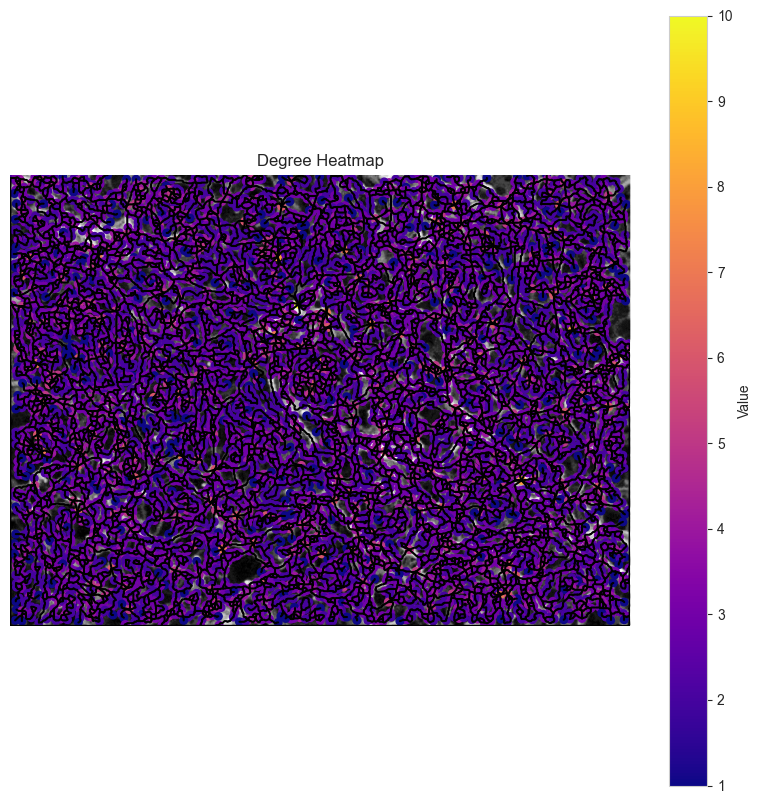

In [33]:
# Degree Heatmap
# Assignment Betweenness Centrality
import networkx as nx

# Compute Degree Distribution
graph = ntwk_obj.graph_obj.nx_graph
deg_distribution_1 = dict(nx.degree(graph))
deg_distribution = np.array(list(deg_distribution_1.values()), dtype=float)
avg_deg = round(np.average(deg_distribution), 5)

# Create plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1)
ax.axis('off')
ax.set_title('Degree Heatmap')

# Add image to plot
ax.imshow(img, cmap='gray')

# Add edges to plot
for (s, e) in graph.edges():
    ge = graph[s][e]['pts']
    ax.plot(ge[:, 1], ge[:, 0], 'black', linewidth=1.5)

# Add nodes to plot
nodes = graph.nodes()
gn = np.array([nodes[i]['o'] for i in nodes])
sc = ax.scatter(gn[:, 1], gn[:, 0], s=30, c=deg_distribution, cmap='plasma')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Value')
plt.show()